In [4]:
import numpy as np
import matplotlib.pyplot as plt

import baccoemu

%matplotlib inline
from classy import Class
from scipy.optimize import fsolve
from scipy.interpolate import interp1d

import jax
jax.config.update("jax_enable_x64", True) 
import jax.numpy as jnp
from discoeb.background import evolve_background
from discoeb.perturbations import evolve_perturbations, get_power, evolve_perturbations_batched

import os 
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"


## Cosmological Parameters
Tcmb    = 2.7255
YHe     = 0.248
Omegam  = 0.3099
Omegab  = 0.049301692328524445
Omegac  = 0.26447041034523616
Omegak  = 0 
w_DE_0  = -1
w_DE_a  = 0.0
cs2_DE  = 1.0
# Initialize neutrinos.
num_massive_neutrinos = 1
mnu     = 0.06  #eV
Tnu     = (4/11)**(1/3) #0.71611 # Tncdm of CLASS
Neff    = 3.046 # -1 if massive neutrino present
N_nu_mass = 1
N_nu_rel = Neff - N_nu_mass * (Tnu/((4/11)**(1/3)))**4
h       = 0.6736
A_s     = 2e-09
n_s     = 0.9649
k_p     = 0.05

# modes to sample
nmodes = 512
kmin = 1e-5
kmax = 1e+2 # 1e+1
aexp = 0.01

In [ ]:
k = np.logspace(-4, np.log10(4.9), 100)
params = {
    'omega_cold': Omegac,
    'omega_baryon': Omegab,
    'hubble': h,
    'ns': n_s,
    'neutrino_mass':0,
    # augmenté
    'A_s': A_s,

    'neutrino_mass': 0.0,
    'w0': -1,
    'wa': 0,
    'expfactor': 1
}

emulator = baccoemu.Matter_powerspectrum(baryonic_model_name='Burger2025')



k_ref, pk_ref = emulator.get_linear_pk(k=k,cold=True,**params)

sigma8_ref = emulator.get_sigma8(cold=True,**params)

params_nl_ref = params.copy()

params_nl_ref['sigma8_cold'] = sigma8_ref
print(params_nl_ref['A_s'],mass,sigma8)
params_nl_ref.pop('A_s')
k_nl_ref, pk_nl_ref = emulator.get_nonlinear_pk(
    k=k,
    cold=True,
    allow_extrapolation=True,
    **params_nl_ref
)


np.savetxt(
    "Pk_cb_massless_z0.txt",
    np.column_stack([k_ref, pk_ref*h**3]),
    header="k[h/Mpc]    Pk[Mpc^3/h^3] (CDM+baryons, z=0, massless neutrinos)"
)

results_bacco = []
results_bacco_nl = []

masses = [0.3]

colors = plt.cm.viridis(np.linspace(0,1,len(masses)))

plt.figure(figsize=(8,5))

for mass, color in zip(masses, colors):

    pars = params.copy()

    pars['neutrino_mass'] = mass
    k_lin, pk_lin = emulator.get_linear_pk(
        k=k,
        cold=True,
        **pars
    )

    ratio_lin = pk_lin / pk_ref
    sigma8 = emulator.get_sigma8(cold=True,**pars)
    pars_nl = pars.copy()

    pars_nl['sigma8_cold'] = sigma8
    print(pars_nl['A_s'],mass,sigma8)
    pars_nl.pop('A_s')

    k_nl, pk_nl = emulator.get_nonlinear_pk(
        k=k,
        cold=True,
        allow_extrapolation=True,
        **pars_nl
    )

    ratio_nl = pk_nl / pk_nl_ref


    fname = f"Pk_cb_sumMnu_{mass:.2f}eV_z0.txt"

    np.savetxt(
        fname,
        np.column_stack([k_lin, pk_lin*h**3]),
        header=f"k[h/Mpc]    Pk[Mpc^3/h^3] (CDM+baryons, z=0, sum m_nu = {mass} eV)"
    )


    results_bacco.append({
        "k": k_lin,
        "ratio": ratio_lin,
        "mass": mass,
        "method": "BACCO"
    })

    results_bacco_nl.append({
        "k": k_nl,
        "ratio": ratio_nl,
        "mass": mass,
        "method": "BACCO_NL"
    })
    
    plt.semilogx(
        k_lin ,
        ratio_lin,
        '--',
        color=color,
        linewidth=2,
        label=fr'${mass}\,\mathrm{{eV}}$ linear'
    )

    plt.semilogx(
        k_nl,
        ratio_nl,
        '-',
        color=color,
        linewidth=2,
        label=fr'${mass}\,\mathrm{{eV}}$ non-linear'
    )

plt.xlabel(r'$k\,[\mathrm{Mpc}^{-1}]$')
plt.ylabel(r'$P^\nu(k)/P(k)$')

plt.grid(True, which='both', ls='--')

plt.legend()

plt.tight_layout()
plt.show()
np.save("bacco_results.npy", results_bacco)
np.save("bacco_results_nl.npy", results_bacco_nl)

KeyError: 'A_s'

In [5]:
def get_class_power( fieldname, zout ):
  tk, k, z = cosmo_massless.get_transfer_and_k_and_z()
  TT = interp1d( np.log(1/(1+z)), tk[fieldname], axis=1 )( np.log(1/(1+zout)) ) 
  #res =  2*np.pi**2*A_s*(k/k_p*h)**(n_s - 1) * k**(-3) * TT**2 
  res =  2*np.pi**2*A_s*(k/k_p)**(n_s - 1) * k**(-3) * TT**2
  return res, k

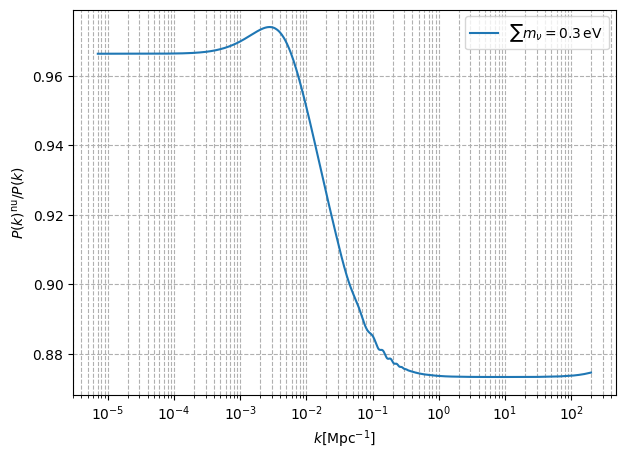

In [9]:
common_settings = {'output': 'mPk'}
zout = 0.0
k = np.logspace(-4, 1, 300)

pk_cb_massless = []
pk_cb_massive = []

plt.figure(figsize=(7,5))
mass_colors = {
    0: "#003f5c",  # dark blue
    0.4: "#bc5090", # magenta
}

cosmo_massless = Class()

params_massless = common_settings.copy()
params_massless.update({
    'Omega_k': 0.0,
    'Omega_b': Omegab,
    'Omega_cdm': Omegac,
    'h': h,
    'A_s': A_s,
    'n_s': n_s,
    'gauge': 'synchronous',
    'reio_parametrization': 'reio_none',
    'k_per_decade_for_pk': 100,
    'k_per_decade_for_bao': 100,
    'T_cmb': Tcmb,
    'YHe': YHe,
    'output': 'mPk,mTk,vTk',
    'P_k_max_1/Mpc': 2 * kmax,
    'z_max_pk': 1000.0,
    'recombination': 'RECFAST',
    'l_max_g': 31,
    'l_max_pol_g': 31,
    'l_max_ur': 31,
    'l_max_ncdm': 31,
    'Omega_Lambda': 0.0,
    'w0_fld': -0.99,
    'wa_fld': 0,
    'cs2_fld': 1.0,
    'use_ppf': 'no',
    'radiation_streaming_approximation': 2,
    'ncdm_fluid_approximation': 3,
    'ur_fluid_approximation': 2,
    'N_ur': 2.046,
    'N_ncdm': 1,
    'm_ncdm': 1e-10
})

cosmo_massless.set(params_massless)
cosmo_massless.compute()
Pknu_CLASS, k_CLASS = get_class_power('d_ncdm[0]', zout)
kmax_used = cosmo_massless.pars['P_k_max_1/Mpc']
mask = k_CLASS <= kmax_used
k_used = k_CLASS[mask]


Pkbc_CLASS = np.array([cosmo_massless.pk_cb(ki, zout) for ki in k_used])

Pkbc_CLASS_hunits = Pkbc_CLASS * h**3

np.savetxt(
    "Pk_cb_massless_z0.txt",
    np.column_stack([k_used, Pkbc_CLASS_hunits]),
    header="k[h/Mpc]    Pk[Mpc^3/h^3] (CDM+baryons, z=0, massless neutrinos)"
)

results_class = []

for sum_masses in [0.3]:

    cosmo_massive = Class()
    pk_cb_massive = []

    params_massive = params_massless.copy()
    params_massive.update({
        'N_ncdm': 1,
        'deg_ncdm': 1,
        'm_ncdm': sum_masses,
        'Omega_cdm': Omegac,
        'N_ur': 2.046
    })

    cosmo_massive.set(params_massive)
    cosmo_massive.compute()



    Pkbc_CLASS_nu = np.array([cosmo_massive.pk_cb(ki, zout) for ki in k_used])

    Pkbc_CLASS_hunits = Pkbc_CLASS_nu * h**3
    fname = f"Pk_cb_sumMnu_{sum_masses:.2f}eV_z0.txt"

    np.savetxt(
        fname,
        np.column_stack([k_used, Pkbc_CLASS_hunits]),
        header=f"k[h/Mpc]    Pk[Mpc^3/h^3] (CDM+baryons, z=0, sum m_nu = {sum_masses} eV)"
    )


    ratio = Pkbc_CLASS_nu / Pkbc_CLASS

    plt.semilogx(
        k_used,
        ratio,
        label=rf'$\sum m_\nu = {sum_masses}\,\mathrm{{eV}}$'
    )

    results_class.append({
        "k": k_used,
        "ratio": ratio,
        "mass": sum_masses,
        "method": "CLASS"
    })

    cosmo_massive.struct_cleanup()
    cosmo_massive.empty()

plt.xlabel(r'$k [\mathrm{Mpc}^{-1}]$')
plt.ylabel(r'$P(k)^\mathrm{nu}/P(k)$')
plt.grid(True, which='both', ls='--')
plt.legend(fontsize=10)
plt.show()

np.save("class_results.npy", results_class)

cosmo_massless.struct_cleanup()
cosmo_massless.empty()

NameError: name 'Line2D' is not defined

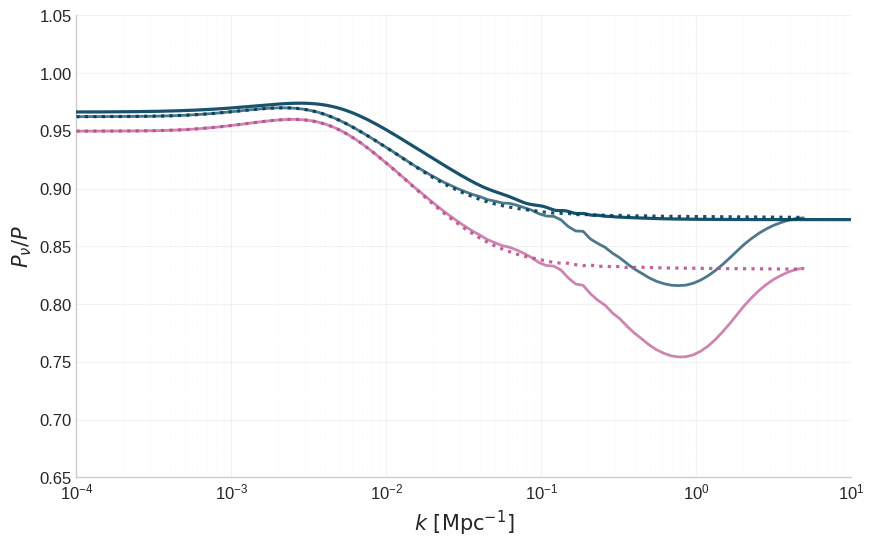

In [10]:



class_data   = np.load("class_results.npy", allow_pickle=True)
bacco_data   = np.load("bacco_results.npy", allow_pickle=True)
bacco_data_nl   = np.load("bacco_results_nl.npy", allow_pickle=True)


all_data = (
      list(class_data)
    + list(bacco_data)
    + list(bacco_data_nl)
   # + list(discoeb_data)
   # + list(discodj_data)
)

plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(10, 6))


masses = sorted(set(d["mass"] for d in all_data))

# Much cleaner palette
mass_colors = {
    0.3: "#003f5c",  # dark blue
    0.4: "#bc5090", # magenta
}

method_styles = {
    "CLASS": dict(
        ls="-",
        lw=2.3,
        alpha=0.9,
        zorder=3,
    ),

    # BACCO linear
    "BACCO": dict(
        ls=":",
        lw=2.3,
        alpha=0.9,
        zorder=3,
    ),

    # BACCO nonlinear
    "BACCO_NL": dict(
        ls="-",
        lw=2.0,
        alpha=0.7,
        zorder=2,
    ),

    "DISCOEB": dict(
        ls="--",
        lw=2.3,
        alpha=0.9,
        zorder=3,
    ),

    "DISCODJ": dict(
        ls="-.",
        lw=2.3,
        alpha=0.9,
        zorder=3,
    ),
}

for d in all_data:

    k       = d["k"]
    ratio   = d["ratio"]
    mass    = d["mass"]
    method  = d["method"]

    color = mass_colors[mass]

    # Important: BACCO_NL avant BACCO
    if "BACCO_NL" in method:
        style = method_styles["BACCO_NL"]

    elif "BACCO" in method:
        style = method_styles["BACCO"]

    elif "CLASS" in method:
        style = method_styles["CLASS"]

    elif "DISCOEB" in method:
        style = method_styles["DISCOEB"]

    elif "DISCODJ" in method:
        style = method_styles["DISCODJ"]

    ax.semilogx(
        k,
        ratio,
        color=color,
        **style
    )

ax.set_xlabel(
    r"$k\ [\mathrm{Mpc}^{-1}]$",
    fontsize=15
)

ax.set_ylabel(
    r"$P_\nu/P$",
    fontsize=15
)

ax.set_xlim(1e-4, 10)
ax.set_ylim(0.65, 1.05)

# Cleaner grid
ax.grid(True, which="major", linestyle="-", alpha=0.25)
ax.grid(True, which="minor", linestyle=":", alpha=0.15)

# Remove top/right borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(axis='both', which='major', labelsize=12)

# ----- Mass legend (colors)
mass_handles = [
    Line2D(
        [0], [0],
        color=mass_colors[m],
        lw=3,
        label=rf"$\sum m_\nu = {m}\ \mathrm{{eV}}$"
    )
    for m in masses
]

# ----- Method legend (linestyles)
method_handles = [
    Line2D(
        [0], [0],
        color="black",
        lw=method_styles[m]["lw"],
        ls=method_styles[m]["ls"],
        alpha=method_styles[m]["alpha"],
        label=m.replace("_", r"_")
        
    )
    for m in method_styles
]

combined_handles = [
    Line2D([], [], color='none', label=r"$\bf{Neutrino\ mass}$"),
    *mass_handles,
    Line2D([], [], color='none', label=""),
    Line2D([], [], color='none', label=r"$\bf{Method}$"),
    *method_handles,
]

legend = ax.legend(
    handles=combined_handles,
    loc="lower left",
    fontsize=11,
    frameon=True,
    handlelength=2.5,
)

legend.get_frame().set_alpha(0.95)

# ============================================================
# TITLE
# ============================================================

ax.set_title(
    r"Massive-to-massless matter power spectrum ratio",
    fontsize=16,
    pad=15
)

plt.tight_layout()

#plt.savefig("comp_in25.pgf", bbox_inches="tight")
plt.show()